In [1]:
global_update_live = True
email_both = True
send_email = True

In [2]:
import pandas as pd
import random
from pydataquery import DataQuery
from matplotlib.colors import LinearSegmentedColormap
from xbbg import blp
import numpy as np
import pytz
import time
from datetime import datetime, timedelta
import statsmodels.api as sm
from ipywidgets import interact, Dropdown, HBox, VBox, Button, Output, Text, widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import re
import scipy.stats as stats
from adjustText import adjust_text
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import sympy as sp
import itertools
import warnings
import openpyxl
import subprocess
import dataframe_image as dfi
import time
import pyautogui
import pygetwindow as gw
import pyodbc
import ast
import json
warnings.filterwarnings("ignore")

In [3]:
with open('Rating_Dict.json', 'r') as f:
    f_dict = json.load(f)

df5a = pd.read_parquet("Basis df5a.parquet")

In [4]:
dt_list = [item.replace("Mat_Matched_CDS_","") for item in df5a.columns if item.startswith("Mat_Matched_CDS")]
last_update = str(max(pd.to_datetime(dt_list)).date())

df5 = df5a.drop([col for col in df5a.columns if "UF100" in col or "UF500" in col], axis=1).copy()
df5 = df5[["ISIN","CUSIP","Name","Maturity","Issuer Equity_red_tier_ccy_docclause"] +\
    [col for col in df5.columns if last_update in col or col.startswith("Basis_")]].copy()

In [5]:
####################################### Zscore and 1Y High/Low Calc

dfz = df5[["ISIN"] + [item for item in df5.columns if "Basis" in item]]
dfz = dfz.set_index("ISIN").T
dfz.index = [pd.to_datetime(item.split("_")[1]).date() for item in dfz.index]
dfz = dfz.sort_index()

all_z_df = None
for period in [3*22, 6*22, 12*22]:
    x = ((dfz-dfz.rolling(period, min_periods = int(0.6*period)).mean())/dfz.rolling(period,\
                  min_periods = int(0.6*period)).std()).iloc[[-1],:].copy()
    x.index = [f'ZScore_{int(period/22)}M']
    all_z_df = pd.concat([all_z_df , x])

max_1y = pd.DataFrame(dfz.iloc[-12*22:,:].max()).T
max_1y.index = [f'Basis 1Y High']
min_1y = pd.DataFrame(dfz.iloc[-12*22:,:].min()).T
min_1y.index = [f'Basis 1Y Low']

all_z_df = pd.concat([all_z_df , max_1y, min_1y])
all_z_df = all_z_df.T
all_z_df = all_z_df.reset_index()

df6 = pd.merge(left=df5.drop([col for col in df5.columns if col.\
    startswith("Basis_") and not last_update in col],axis=1),\
               right=all_z_df, on="ISIN", how="inner").drop(["CUSIP","Maturity"],axis=1).copy()

In [6]:
try:
    df7 = df6.drop(f"Dur_{last_update}",axis=1).copy()
except:
    df7 = df6.copy()
df7["Family"] = df7["Issuer Equity_red_tier_ccy_docclause"].apply(lambda x: f_dict[x])
df7["CDS RED Code"] =  df7["Issuer Equity_red_tier_ccy_docclause"].apply(lambda x: x.split("_")[1])
df7.columns = df7.columns.str.replace(f"_{last_update}","").str.replace("Mat_Matched_CDS","Mat. Matched CDS")
df7["First Sort"] = df7["Name"].apply(lambda x: x.split(" ")[0])
df7["Second Sort"] = df7["Name"].apply(lambda x: x.rsplit("/")[-1])

df7 = df7.sort_values(by=["First Sort","Second Sort"],ascending=[True, True])
df7 = df7.drop(["ISIN","Issuer Equity_red_tier_ccy_docclause","First Sort","Second Sort"], axis=1).set_index("Name").copy()

df7 = df7[["Family","CDS RED Code","Price","Sprd","Mat. Matched CDS","Basis","Basis 1Y Low","Basis 1Y High",\
           "ZScore_3M","ZScore_6M","ZScore_12M"]].copy()
df7 = round(df7,2)

In [7]:
for family in ["HY","IG","EUR_HY", 'EUR_IG', 'SNRFIN', 'SUBFIN']:
    df8 = df7[df7["Family"]==family].copy()
    df8["Issuer"] = [item.split(" ")[0] for item in df8.index]
    issuers = df8["Issuer"].to_list()
    all_corp_z = pd.DataFrame(columns={"Family":[],"Basis 3M ZScore":[],"Basis 6M ZScore":[],"Basis 12M ZScore":[]})
    for issuer in issuers:
        all_corp_z.loc[issuer] = list(set(df8[df8["Issuer"] == issuer]["Family"])) +\
        list(df8[df8["Issuer"] == issuer][["ZScore_3M","ZScore_6M","ZScore_12M"]].median(axis=0))
    all_corp_z = round(all_corp_z.drop("Family",axis=1),1)
    globals()[f'df_{family}'] = all_corp_z.copy()

In [8]:
ig_bank = df6[(df6['Name'].apply(lambda x: x.split(' ')[0]).isin(df_IG.index))]
ig_bank1 = list(set(ig_bank["Issuer Equity_red_tier_ccy_docclause"].apply(lambda x: x.split('_')[0])))
ig_bank1 = [item+' EQUITY' for item in ig_bank1]
x = blp.bdp(tickers=ig_bank1, flds=['BICS_LEVEL_1_SECTOR_NAME','BICS_LEVEL_2_INDUSTRY_GROUP_NAME','BB_ISSR_COMP_BSE_ON_RTGS'])
y = x[(x['bb_issr_comp_bse_on_rtgs'].apply(lambda x: str(x)[0])=='A') & (x['bics_level_1_sector_name']=='Financials')].index
y = [item.rsplit(' ',1)[0] for item in y]
# y = [item.rsplit(' ',1)[0] for item in x[x[x.columns[0]]=='Financials'].index]
ig_bank = ig_bank[ig_bank["Issuer Equity_red_tier_ccy_docclause"].apply(lambda x: x.split('_')[0]).isin(y)]
ig_bank = list(sorted(ig_bank['Name']))

In [9]:
df7a = df7.copy()
df7a = df7a[df7a.index.isin(ig_bank)]

In [10]:
def color_negative_red_positive_green_basis(col: pd.Series):
    if col.empty:
        return ['' for _ in col]
    float_col = col[col.apply(lambda x: isinstance(x, float))]
    min_val, max_val = float_col.min(), float_col.max()
    def value_to_color(val):
        if not isinstance(val, float):
            return ''
        if val < 0 and min_val < 0:
            frac = val/ min_val
            frac = max(min(frac,1),0)
            r = int(255 - (255 - 87) * frac)
            g = int(255 - (255 - 187) * frac)
            b = int(255 - (255 - 138) * frac)
            a = 0.75
            return f'background-color: rgb({r},{g},{b},{a})'
        elif val > 0 and max_val > 0:
            frac = val/ max_val
            frac = max(min(frac,1),0)
            r = int(255 - (255 - 230) * frac)
            g = int(255 - (255 - 135) * frac)
            b = int(255 - (255 - 115) * frac)
            a = 0.75
            return f'background-color: rgb({r},{g},{b},{a})'
        return ''
    return [value_to_color(v) for v in col]

def add_vertical_lines(df):
    styles = pd.DataFrame('', index=df.index, columns=df.columns)
    for i in range(1, len(df.columns), 2):
        styles.iloc[:, i] = 'border-right: 8px solid black;'
    return styles
    
def style_rich_cheap_basis(df):
    styled_df = df.style.apply(color_negative_red_positive_green_basis, subset=df.columns[-3:], axis=0)
    styled_df = styled_df.format(precision=2)
    styled_df = styled_df.format(precision=0, subset=df.columns[2:7])
    styled_df = styled_df.format(precision=1, subset=df.columns[-3:])
    styled_df = styled_df.set_properties(**{'text-align': 'center'})
    styled_df = styled_df.applymap(lambda val: 'font-weight: bold', subset=pd.IndexSlice[:, df.columns[4]])
    return styled_df
    
# for rating_col in ["IG","HY","EUR_IG","EUR_HY","SNRFIN","SUBFIN"]:
rating_col = 'Banks'
df1 = df7a.drop("Family",axis=1)
df1["Issuer"] = [item.split(" ")[0] for item in df1.index]

num_issuers = len(set([item.split(" ")[0] for item in df1.index]))

issuers_per_table = 1
# issuers_list = list(sorted(set([item.split(" ")[0] for item in df1.index])))
issuers_list = list(sorted(set(df1["Issuer"])))

for i in range(int(num_issuers/issuers_per_table)+1):
    globals()[f'df_{i}'] = df1[df1["Issuer"].isin(issuers_list[issuers_per_table*i:issuers_per_table*i+issuers_per_table])].copy()

modified_dfs = []

for i in range(int(num_issuers / issuers_per_table) + 1):
    df = globals()[f'df_{i}'].reset_index().copy()
    new_df = pd.DataFrame(columns=df.columns)
    
    for issuer in df['Issuer'].unique():
        issuer_rows = df[df['Issuer'] == issuer]
        new_df = pd.concat([new_df, issuer_rows], ignore_index=True)
        empty_row = pd.Series([''] * len(df.columns), index=df.columns)
        new_df = pd.concat([new_df, pd.DataFrame([empty_row])], ignore_index=True)
    globals()[f'df_{i}'] = new_df.set_index(new_df.columns[0]).drop("Issuer",axis=1).copy()                

    
for i in range(int(num_issuers / issuers_per_table) + 1):
    df = globals()[f'df_{i}'].copy()
    index_counts = {}
    new_index = []
    
    for idx in df.index:
        if idx in index_counts:
            index_counts[idx] += 1
            # new_index.append(f"{idx}_{index_counts[idx]}")
            new_index.append(f"{idx}{'_' * index_counts[idx]}{pd.to_datetime(last_update).strftime("%d-%b")}")

        else:
            count = df.index.tolist().count(idx)
            if count > 1:
                index_counts[idx] = 1
                new_index.append(f"{idx}_{pd.to_datetime(last_update).strftime("%d-%b")}")
            else:
                new_index.append(idx)
    df.index = new_index
    df.index.name = f'{pd.to_datetime(last_update).strftime("%d-%b")}'
    globals()[f'display_df_{i}'] = style_rich_cheap_basis(df.iloc[:-1,:])
    globals()[f'display_df_{i}'] = globals()[f'display_df_{i}'].set_table_styles(
        [
            {'selector': 'tr', 'props': [('width', '8px')]},
            {'selector': 'th, td', 'props': [('line-height', '8px')]}
        ],)

    dfi.export(globals()[f'display_df_{i}'] , f'Plots/Banks/{rating_col}_{i}.png', table_conversion='chrome', dpi=100)

In [11]:
issuers = list(set([item.split(' ')[0] for item in df7a.index]))
df7b = df7a.iloc[:,-3:].reset_index().copy()
df7b['Composite'] = round(abs(df7b['ZScore_3M'] * df7b['ZScore_6M'] * df7b['ZScore_12M']),2)
df7b = df7b.sort_values(by='Composite',ascending=False)

bonds_to_scatter = {}
for item in issuers:
    l1 = df7b[df7b['Name'].apply(lambda x: x.split(' ')[0])==item]['Name'][:2].to_list()
    l1 = [item.rsplit(' ',1)[0] + '% due ' + item.split('/')[-1] for item in l1]
    bonds_to_scatter[item] = l1

In [12]:
all_corp = None
corp = df5a[["Name"] + [item for item in df5a.columns if item.startswith("Mat_Matched_CDS_")]].copy()
corp = corp.set_index("Name").T
corp.index = [item.replace("Mat_Matched_CDS_","") for item in corp.index]
l = [item.rsplit(" ",1)[0] + "% due " + item.rsplit("/",1)[1] + " Mat. Matched CDS" for item in corp.columns]
corp.columns = l
all_corp = corp.copy()

corp = df5a[["Name"] + [item for item in df5a.columns if item.startswith("Basis_")]].copy()
corp = corp.set_index("Name").T
corp.index = [item.replace("Basis_","") for item in corp.index]
l = [item.rsplit(" ",1)[0] + "% due " + item.rsplit("/",1)[1] + " Basis" for item in corp.columns]
corp.columns = l
all_corp = pd.concat([all_corp, corp],axis=1)
all_corp.index = pd.to_datetime(all_corp.index)
all_bonds = all_corp.copy()
all_bonds.loc[pd.to_datetime('2023-03-13'), 'BRK 1.45% due 30 Basis'] = -34.2

In [13]:
# def scatter(variant):
#     uf_scatter = df5a[["Name"] + [col for col in df5a.columns if col.\
#         startswith(f"Mat_Matched_UF{variant}_") or col.startswith(f"UF{variant}_Basis_")]]
#     uf_scatter["Name"] = uf_scatter["Name"].apply(lambda x: x.rsplit(" ",1)[0] + "% due " + x.rsplit("/")[-1])
#     uf_scatter = uf_scatter.set_index("Name")
#     uf_scatterA = uf_scatter[[col for col in uf_scatter.columns if col.startswith(f"Mat_Matched_UF{variant}_")]]
#     uf_scatterA.columns = pd.to_datetime([item.rsplit("_",1)[1] for item in uf_scatterA.columns])
#     uf_scatterA = uf_scatterA.T
#     # uf_scatterA.columns = [item + f" Mat Matched UF{variant}" for item in uf_scatterA.columns]
#     uf_scatterA.columns = [item + f" Mat. Matched CDS" for item in uf_scatterA.columns]
    
#     uf_scatterB = uf_scatter[[col for col in uf_scatter.columns if col.startswith(f"UF{variant}_Basis_")]]
#     uf_scatterB.columns = pd.to_datetime([item.rsplit("_",1)[1] for item in uf_scatterB.columns])
#     uf_scatterB = uf_scatterB.T
#     # uf_scatterB.columns = [item + f" Basis UF{variant}" for item in uf_scatterB.columns]
#     uf_scatterB.columns = [item + f" Basis" for item in uf_scatterB.columns]
    
#     uf_scatter = pd.concat([uf_scatterA, uf_scatterB],axis=1).sort_index()
#     return uf_scatter

# uf100_scatter = scatter("100")
# uf500_scatter = scatter("500")

In [14]:
def gen_plots(bond_name, df, fam, pic_num, cdx_label=False, variant=False):
    f = df[[f"{bond_name} Mat. Matched CDS",f"{bond_name} Basis"]].dropna().copy()
    f = f[f.index>pd.to_datetime("2021-01-01")]
    plt.figure(figsize=(12,6))
    plt.scatter(f[f"{bond_name} Mat. Matched CDS"].iloc[:-252], f[f"{bond_name} Basis"].iloc[:-252], color="gray")
    plt.scatter(f[f"{bond_name} Mat. Matched CDS"].iloc[-252:-63], f[f"{bond_name} Basis"].iloc[-252:-63], color="blue")
    plt.scatter(f[f"{bond_name} Mat. Matched CDS"].iloc[-63:-1], f[f"{bond_name} Basis"].iloc[-63:-1], color="green")
    plt.scatter(f[f"{bond_name} Mat. Matched CDS"].iloc[-1], f[f"{bond_name} Basis"].iloc[-1], color="red")          
    
    x_scatter = f[f"{bond_name} Mat. Matched CDS"]
    y_scatter = f[f"{bond_name} Basis"]
    
    coeffs = np.polyfit(x_scatter,y_scatter,2)
    polynomial = np.poly1d(coeffs)
    x_poly=np.linspace(min(x_scatter),max(x_scatter),500)
    y_poly=polynomial(x_poly)
    y_pred = polynomial(x_scatter)
    r2=r2_score(y_scatter,y_pred)
    equation_text = f"y = {coeffs[0]:.4f}*x² + {coeffs[1]:.4f}*x + {coeffs[2]:.4f}"
    
    residuals = y_scatter-y_pred
    res_sum=np.sum(residuals**2)
    dof=len(x_scatter)-len(coeffs)
    res_var = res_sum / dof
    se = np.sqrt(res_var)
    conf_upper = y_poly + 2 * se
    conf_lower = y_poly - 2 * se
    
    plt.scatter(x_poly, y_poly,color="orange",s=2)
    plt.scatter(x_poly, conf_upper,color="orange",s=2)
    plt.scatter(x_poly, conf_lower,color="orange",s=2)
    
    plt.fill_between(x_poly, conf_lower, conf_upper, color="orange", alpha=0.1)
    
    plt.title(f"{bond_name} from {f.index[0].date()} to {f.index[-1].date()}{f" ({variant} bps CPN)" if variant else ""}")
    plt.ylabel(f"{bond_name} Basis ({"pts" if cdx_label==True else "bps"})")
    plt.xlabel(f"{bond_name} Mat. Matched CDS ({"pts" if cdx_label==True else "bps"})")
    plt.savefig(f'J:\\All Data\\53A. HY Bonds Basis Email\\Email Plots\\Scatter Plots2\\Banks\\{datetime.\
        now().date()}_{fam.replace("_"," ")}_{pic_num}.png')
    plt.show()

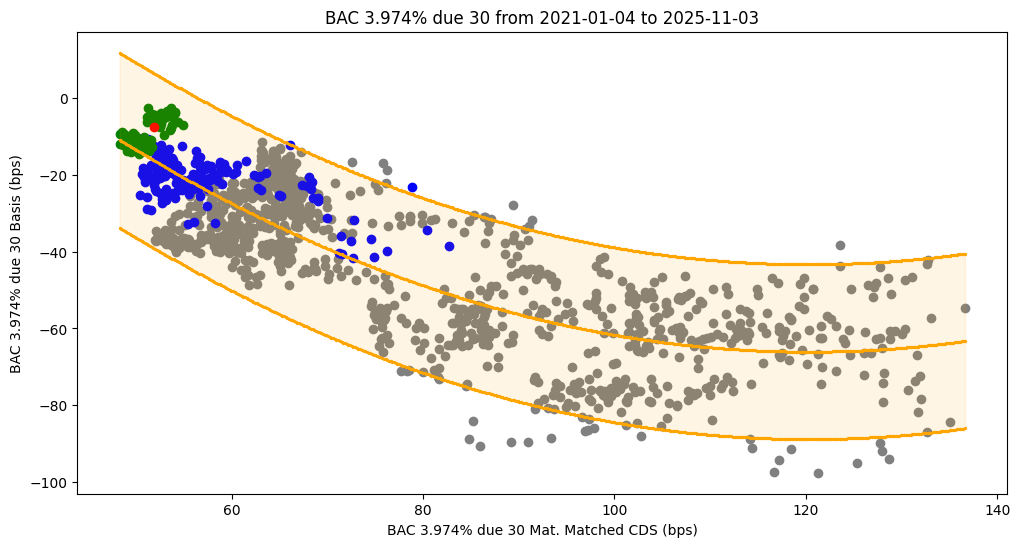

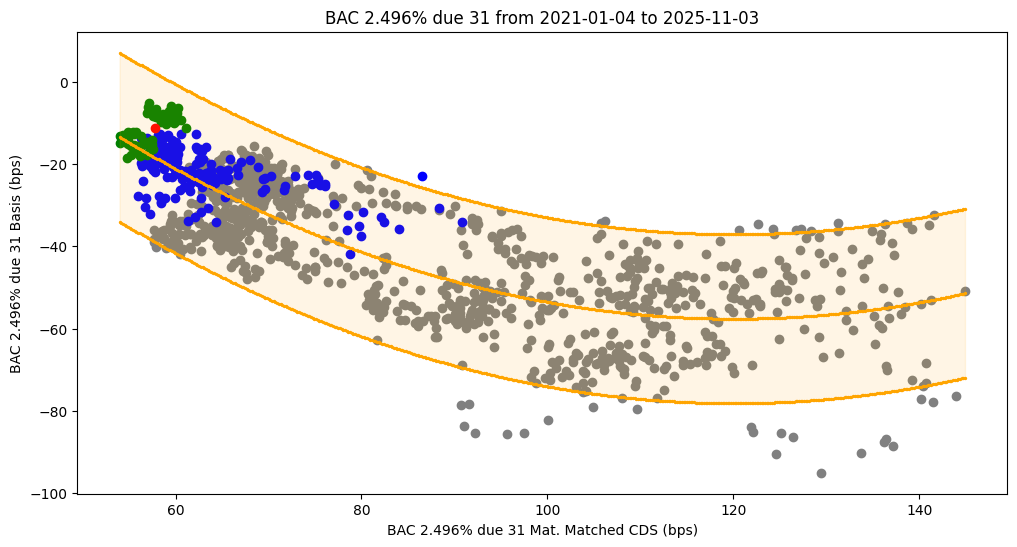

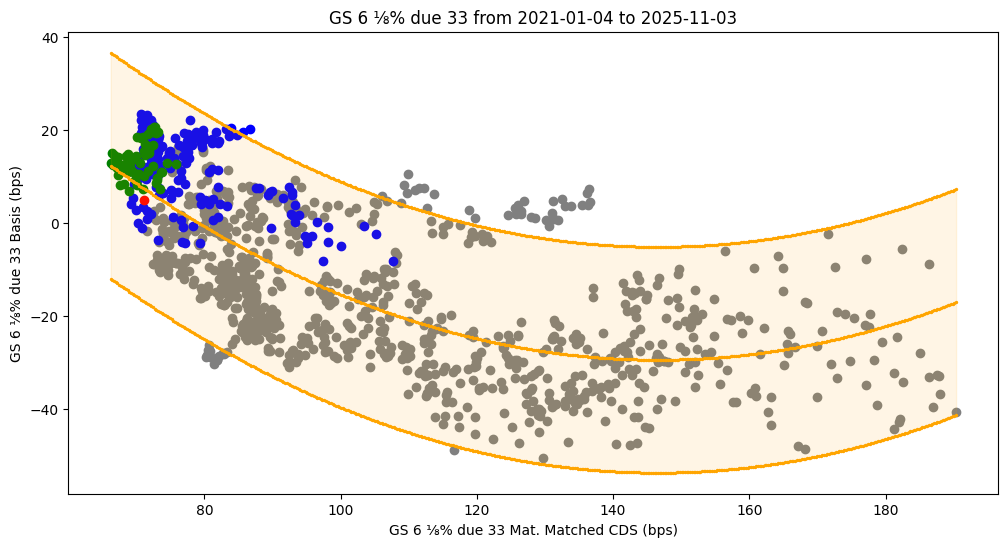

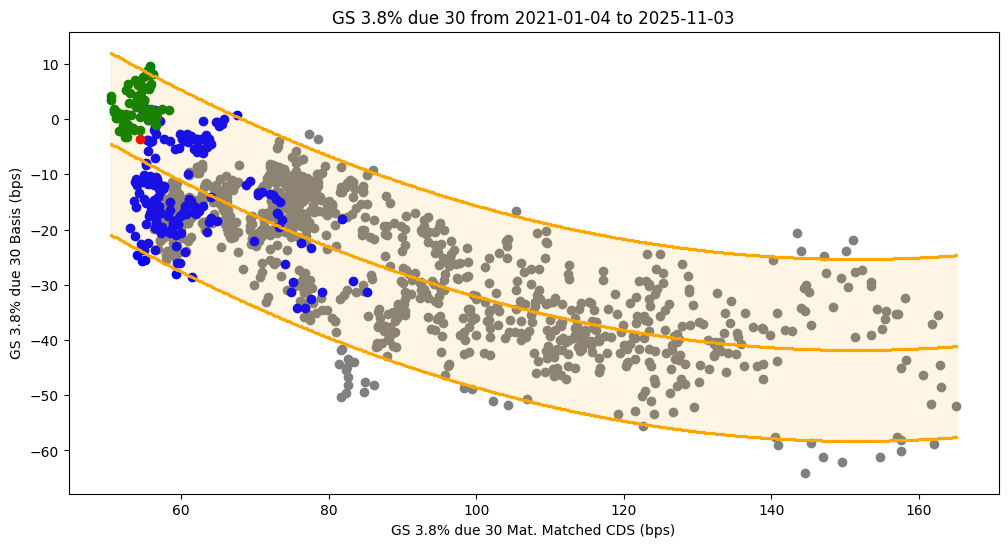

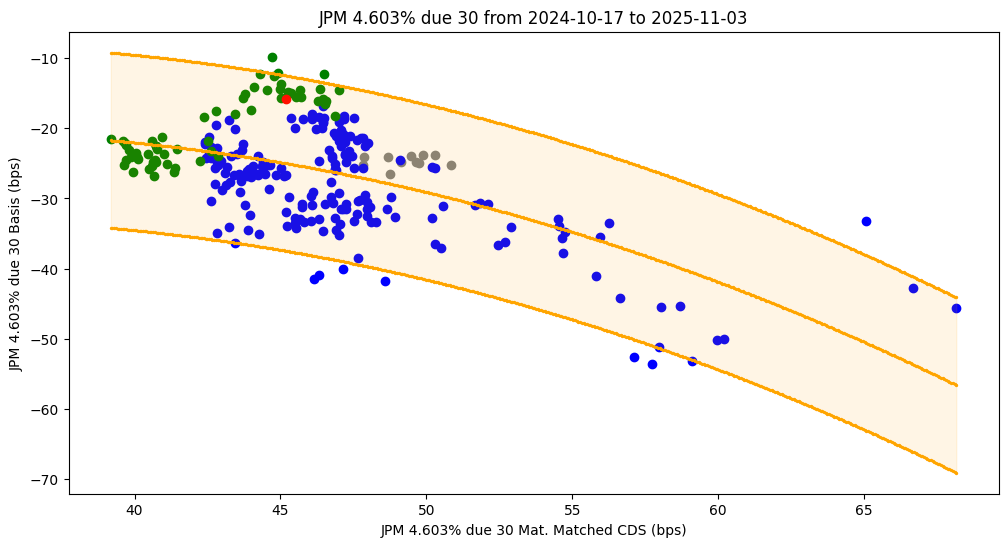

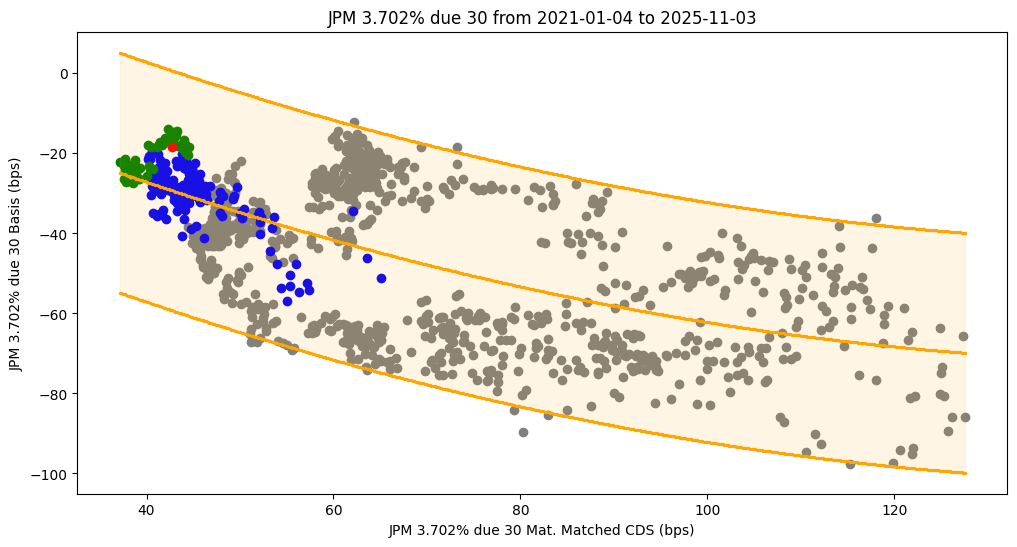

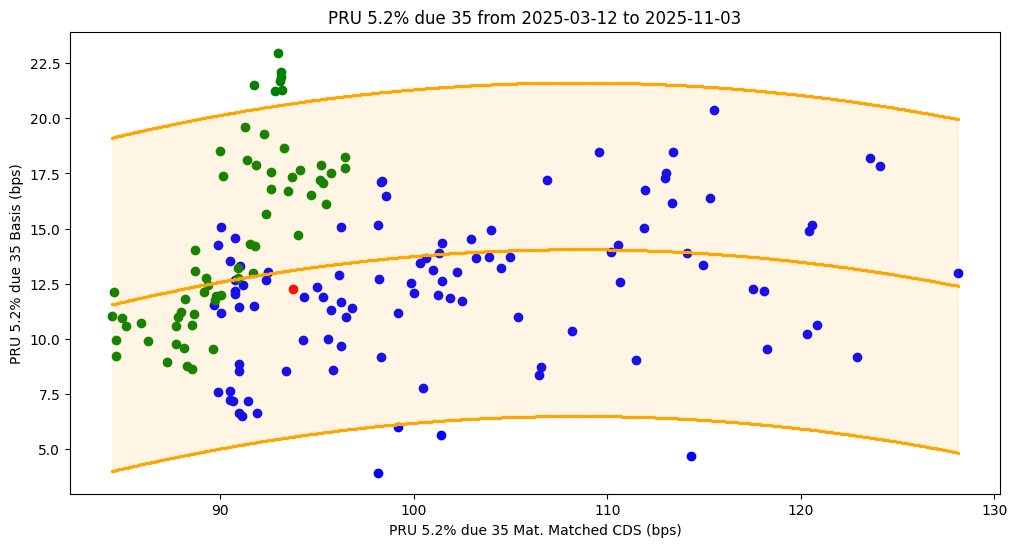

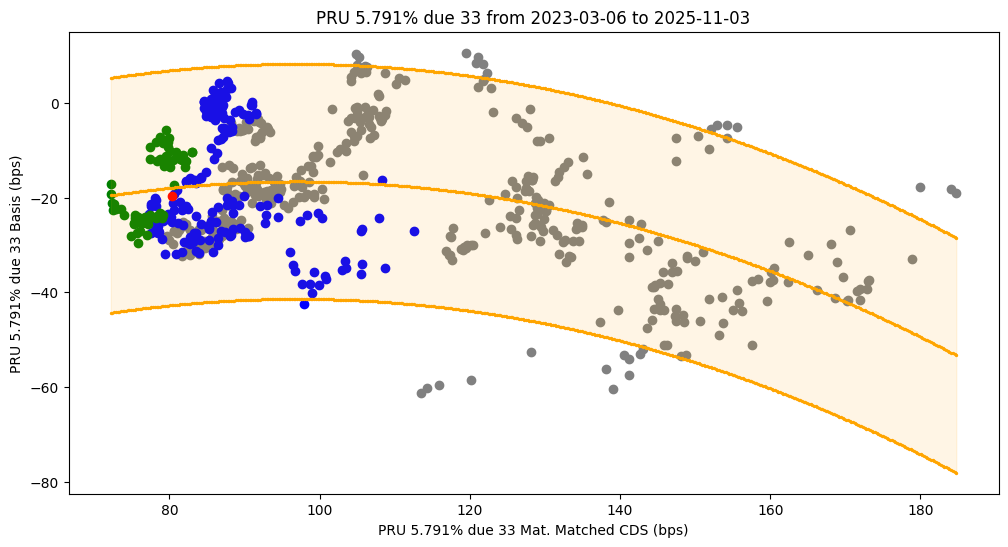

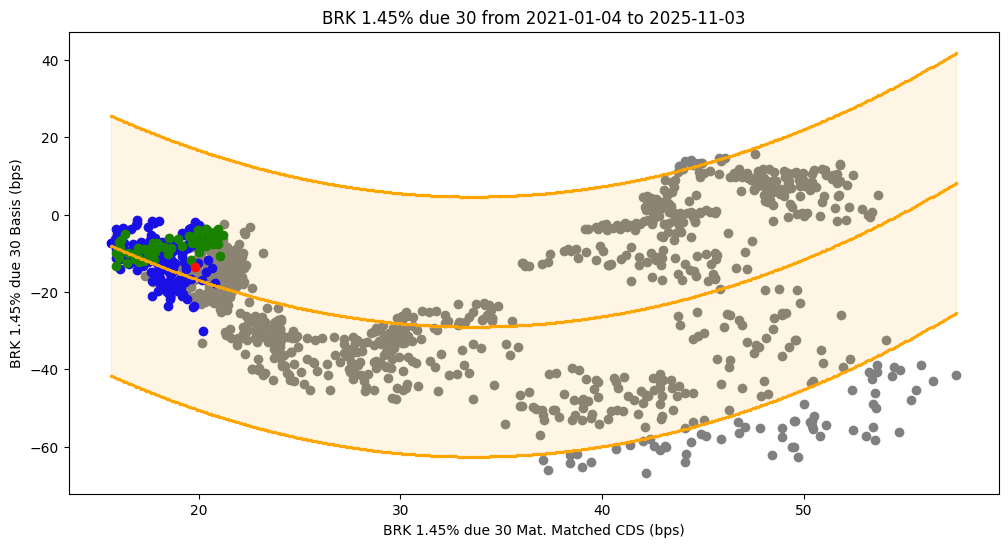

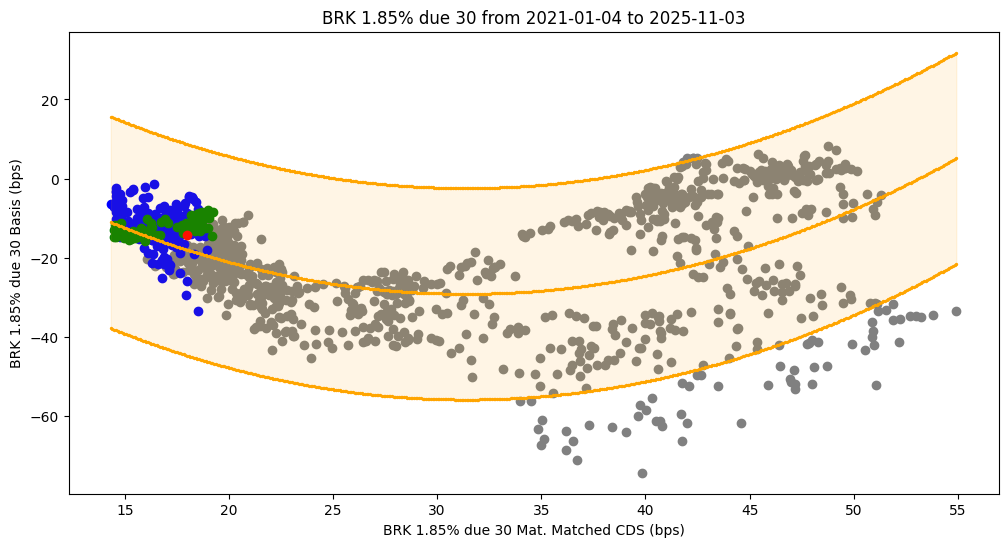

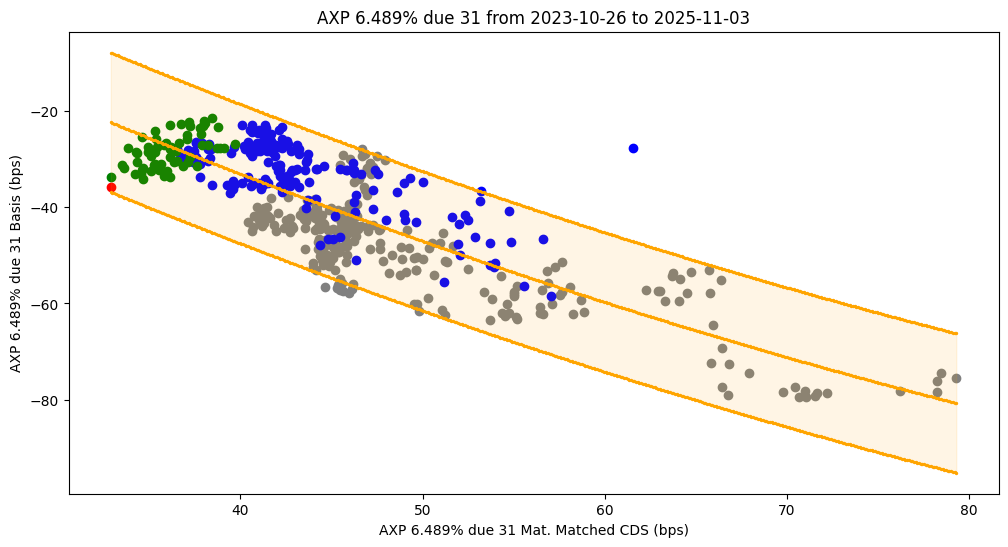

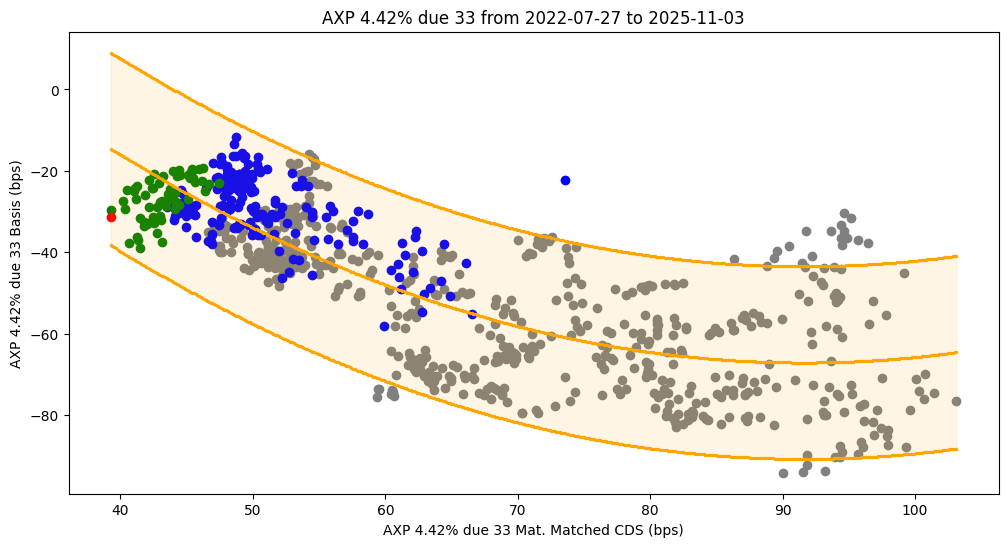

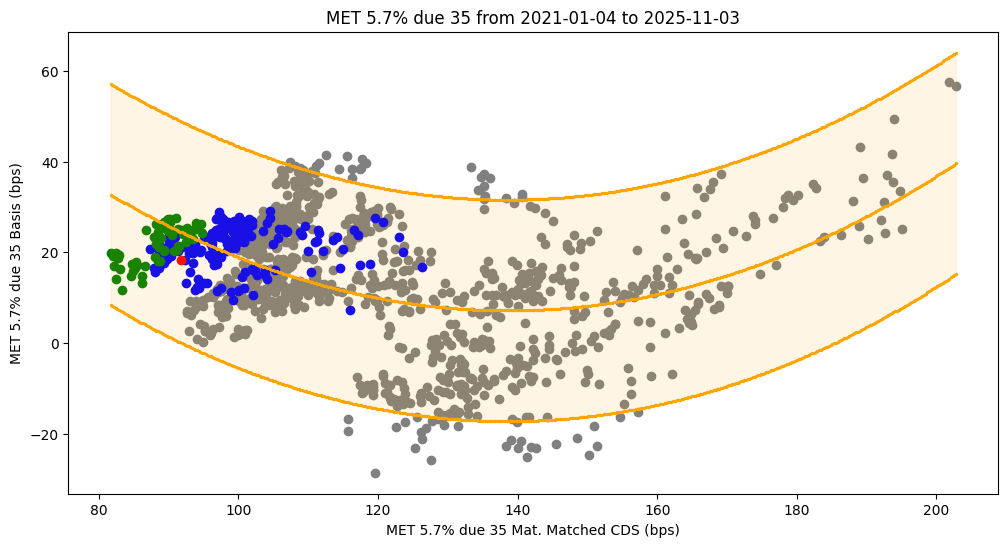

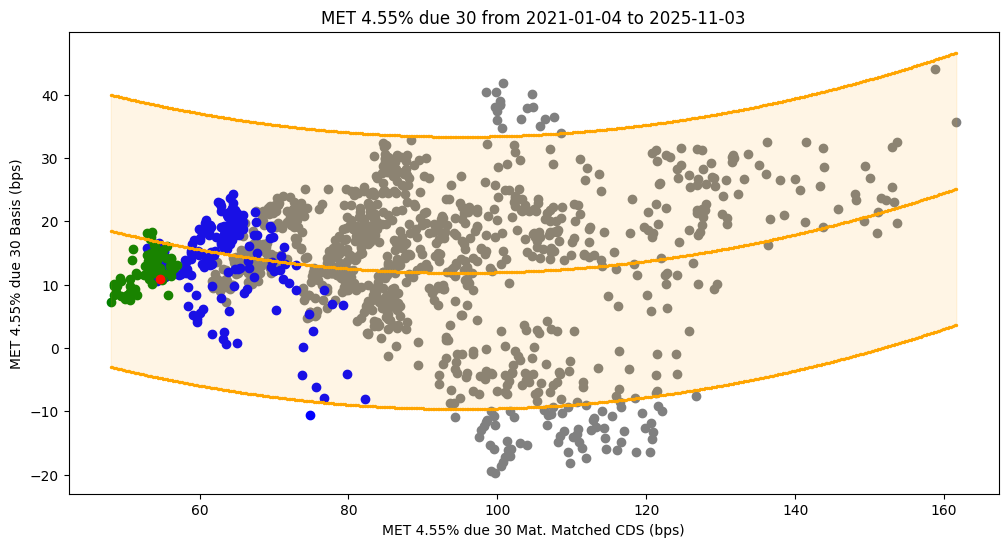

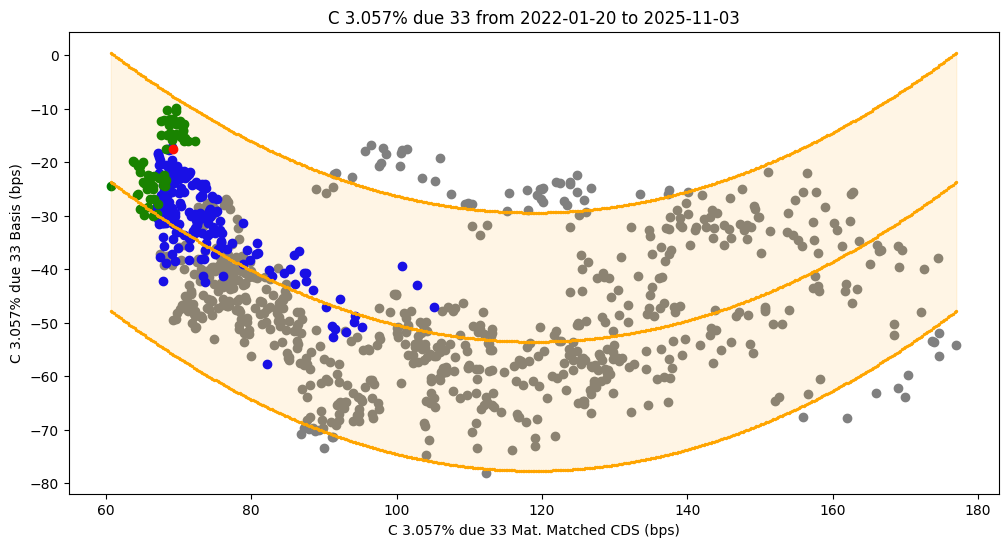

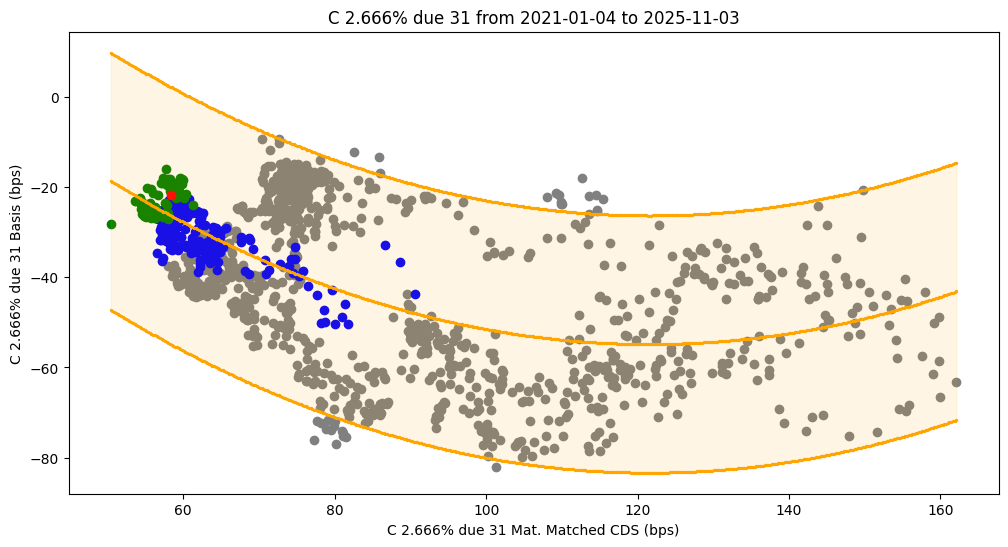

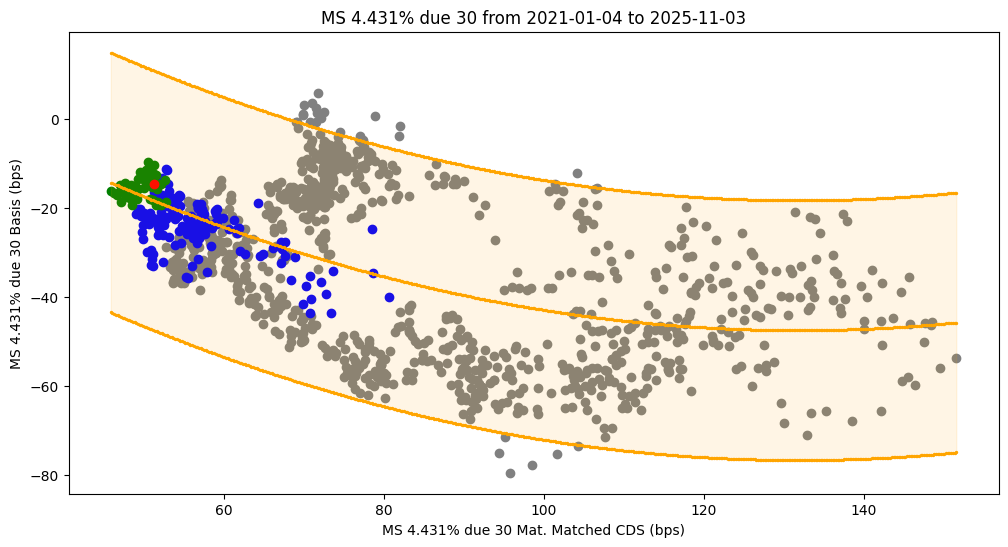

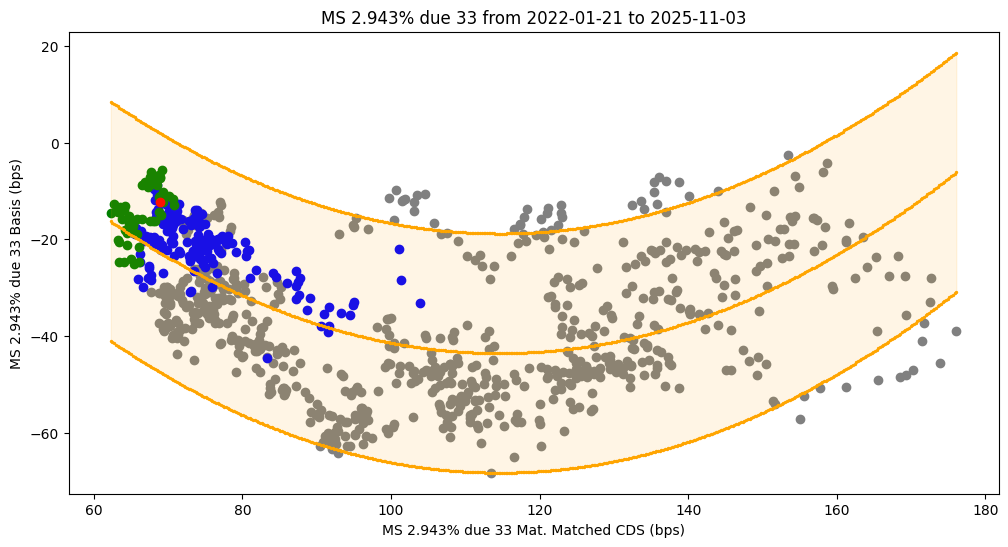

In [15]:
for key, val in bonds_to_scatter.items():
    gen_plots(val[0], all_bonds, key, 0)
    gen_plots(val[1], all_bonds, key, 1)

In [16]:
import os
import win32com.client
import glob
import pandas as pd
import dataframe_image as dfi
from io import BytesIO
import tempfile

html_body = "<html><body>"

outlook = win32com.client.Dispatch("Outlook.Application")
mail = outlook.CreateItem(0)

folder_path = f'J:\\All Data\\53A. HY Bonds Basis Email\\Plots\\Banks'
png_files = glob.glob(os.path.join(folder_path, '*.png'))
png_files = [item for item in png_files if f"{rating_col}_" in item]
png_files.sort(key=lambda x: int(os.path.splitext(os.path.basename(x))[0].rsplit("_")[-1]))

for png_file in png_files:
    raw_name = os.path.splitext(os.path.basename(png_file))[0]
    image_cid = raw_name.replace(" ", "_")
    attachment = mail.Attachments.Add(Source=png_file)
    attachment.PropertyAccessor.SetProperty("http://schemas.microsoft.com/mapi/proptag/0x3712001F", image_cid)
    html_body += f'<img src="cid:{image_cid}"><br><br><br>'

folder_path = f'J:\\All Data\\53A. HY Bonds Basis Email\\Email Plots\\Scatter Plots2\\Banks\\'
png_files = glob.glob(os.path.join(folder_path, '*.png'))
png_files = [item for item in png_files if str(datetime.now().date()) in item]

for png_file in png_files:
    raw_name = os.path.splitext(os.path.basename(png_file))[0]
    image_cid1 = raw_name.replace(" ", "_")
    attachment = mail.Attachments.Add(Source=png_file)
    attachment.PropertyAccessor.SetProperty("http://schemas.microsoft.com/mapi/proptag/0x3712001F", image_cid1)
    html_body += f'<img src="cid:{image_cid1}"><br><br><br>'


html_body += '</body></html>'

mail.HTMLBody = html_body
mail.Subject = f'Banks Basis (auto)'
mail.CC = 'vasu.sharma@iiicm.com'
if email_both:
    mail.To = 'spyros.michas@iiicm.com'
if send_email:
    mail.Send()
    print("Sent")
# mail.Send()

Sent
